# 1. 이미지 불러오기

## pillow

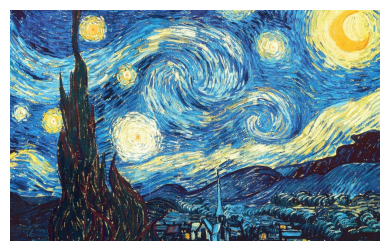

In [5]:
import matplotlib.pyplot as plt
from PIL import Image

from lib.utils.path import images_path

image_path = str(images_path() / 'starry_night.jpg')
image = Image.open(image_path)

plt.figure(figsize=(5, 3))
plt.imshow(image)
plt.axis('off')
plt.show()

## opencv

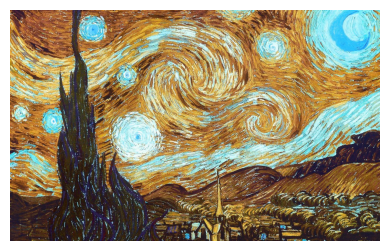

In [6]:
import cv2

from lib.utils.path import images_path

image_path = str(images_path() / 'starry_night.jpg')
image_cv2 = cv2.imread(image_path)

plt.figure(figsize=(5, 3))
plt.imshow(image_cv2)
plt.axis('off')
plt.show()

In [7]:
# image와 image_cv 차이 파악하기
import numpy as np

print(f'pillow: {np.array(image)[0][0]}')  # R, G, B
print(f'opencv: {image_cv2[0][0]}')  # B, G, R


pillow: [  6  22 109]
opencv: [109  22   6]


# 2. 이미지 변환하기

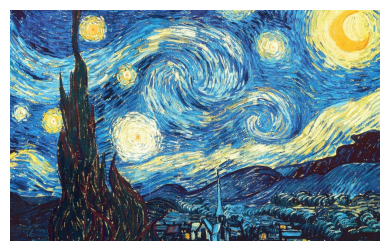

In [ ]:
image_cv2_rgb = cv2.cvtColor(image_cv2, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(5, 3))
plt.imshow(image_cv2_rgb, cmap='gray')
plt.axis('off')
plt.show()

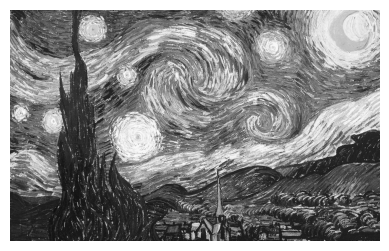

In [14]:
image_cv2_rgb_gray = cv2.cvtColor(image_cv2, cv2.COLOR_BGR2GRAY)

plt.figure(figsize=(5, 3))
plt.imshow(image_cv2_rgb_gray, cmap='gray')
plt.axis('off')
plt.show()

# 3. 이미지 정보 파악하기

In [12]:
print(type(image_cv2))
print(image_cv2.shape)
print(image_cv2.ndim)
print(image_cv2.dtype)
print(image_cv2.size)

<class 'numpy.ndarray'>
(640, 1024, 3)
3
uint8
1966080


# 4. 이미지 저장하기

In [15]:
save_path = str(images_path() / 'starry_night_gray.jpg')

cv2.imwrite(save_path, image_cv2_rgb_gray)

True

# 5. 이미지 그리기

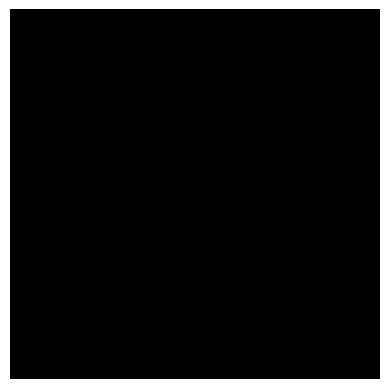

In [ ]:
import cv2
import numpy as np

image = np.zeros((200, 200, 3), dtype=np.uint8)

plt.imshow(image)
plt.axis('off')
plt.show()

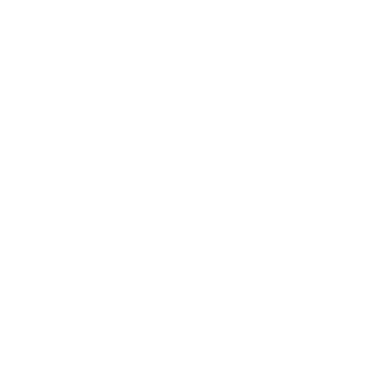

In [18]:
import cv2
import numpy as np

image = np.ones((200, 200, 3), dtype=np.uint8) * 255

plt.imshow(image)
plt.axis('off')
plt.show()

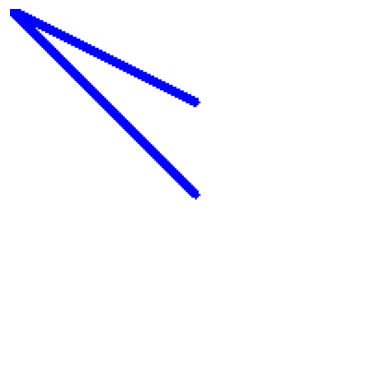

In [19]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

image = np.ones((200, 200, 3), dtype=np.uint8) * 255

cv2.line(image, (0, 0), (100, 100), (0, 0, 255), 3, lineType=cv2.FILLED)
cv2.line(image, (0, 0), (100, 50), (0, 0, 255), 3, lineType=cv2.LINE_4)

plt.imshow(image)
plt.axis('off')
plt.show()

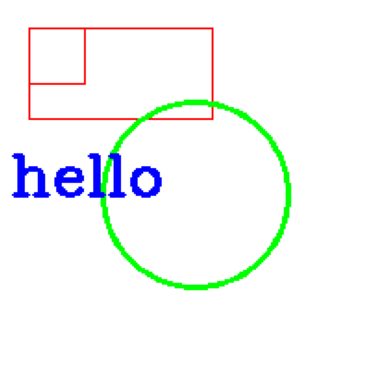

In [23]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

image = np.ones((200, 200, 3), dtype=np.uint8) * 255

cv2.rectangle(image, (10, 10), (40, 40), (255, 0, 0), 1)
cv2.rectangle(image, (10, 10, 100, 50), (255, 0, 0), 1)
cv2.circle(image, (100, 100), 50, (0, 255, 0), 2)
cv2.putText(image, 'hello', (0, 100), cv2.FONT_HERSHEY_COMPLEX, 1, (0, 0, 255), 2)

plt.imshow(image)
plt.axis('off')
plt.show()

# 6. 마스크 씌우기

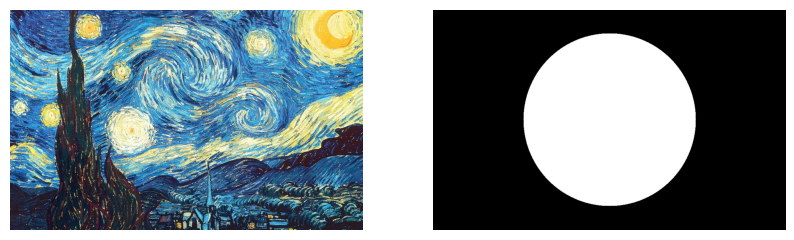

In [27]:
import cv2
import matplotlib.pyplot as plt

from lib.utils.path import images_path

image_path = images_path() / 'starry_night.jpg'
mask_path = images_path() / 'circle.jpg'

image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

mask = cv2.imread(mask_path)
mask = cv2.cvtColor(mask, cv2.COLOR_BGR2RGB)

fig, ax = plt.subplots(1, 2, figsize=(10, 4))

ax[0].imshow(image)
ax[0].axis('off')
ax[1].imshow(mask)
ax[1].axis('off')

plt.show()


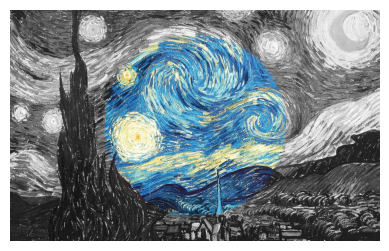

In [24]:
import cv2
import matplotlib.pyplot as plt

from lib.utils.path import images_path

image1_path = images_path() / 'starry_night.jpg'
image2_path = images_path() / 'circle.jpg'

image1 = cv2.imread(image1_path)
image1 = cv2.cvtColor(image1, cv2.COLOR_BGR2RGB)
mask = cv2.imread(image2_path, cv2.IMREAD_GRAYSCALE)
dst = cv2.imread(images_path() / 'starry_night_gray.jpg')

cv2.copyTo(image1, mask, dst)

plt.figure(figsize=(5, 3))
plt.imshow(dst)
plt.axis('off')
plt.show()

# 7. 이미지 처리

## 1) 색상 추출

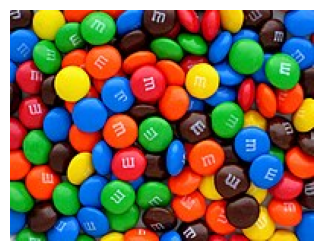

In [28]:
import cv2

from lib.utils.path import images_path

image_path = images_path() / 'chocolate.jpg'

image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(5, 3))
plt.imshow(image)
plt.axis('off')
plt.show()

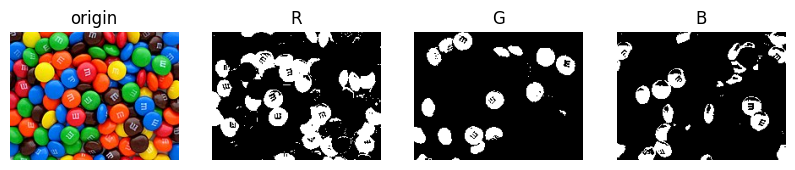

In [30]:
mask_r = cv2.inRange(image, (128, 0, 0), (255, 128, 128))
mask_g = cv2.inRange(image, (0, 128, 0), (128, 255, 128))
mask_b = cv2.inRange(image, (0, 0, 128), (128, 128, 255))

fig, ax = plt.subplots(1, 4, figsize=(10, 4))
ax[0].imshow(image)
ax[0].set_title('origin')
ax[0].axis('off')

ax[1].imshow(mask_r, cmap='gray')
ax[1].set_title('R')
ax[1].axis('off')

ax[2].imshow(mask_g, cmap='gray')
ax[2].set_title('G')
ax[2].axis('off')

ax[3].imshow(mask_b, cmap='gray')
ax[3].set_title('B')
ax[3].axis('off')

plt.show()

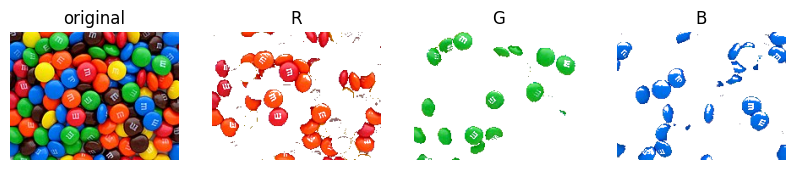

In [31]:
# copyTo(image, mask, dst) : original에서 mask를 뽑아서 흰 도화지에 붙인다.
white_dst = np.ones(image.shape, dtype=np.uint8) * 255
image_R = cv2.copyTo(image, mask_r, white_dst)

white_dst = np.ones(image.shape, dtype=np.uint8) * 255
image_G = cv2.copyTo(image, mask_g, white_dst)

white_dst = np.ones(image.shape, dtype=np.uint8) * 255
image_B = cv2.copyTo(image, mask_b, white_dst)

fig, ax = plt.subplots(1, 4, figsize=(10, 4))
ax[0].imshow(image)
ax[0].set_title('original')
ax[0].axis('off')
ax[1].imshow(image_R, cmap='gray')
ax[1].set_title('R')
ax[1].axis('off')
ax[2].imshow(image_G, cmap='gray')
ax[2].set_title('G')
ax[2].axis('off')
ax[3].imshow(image_B, cmap='gray')
ax[3].set_title('B')
ax[3].axis('off')
plt.show()

## 2) 가우시안 블러

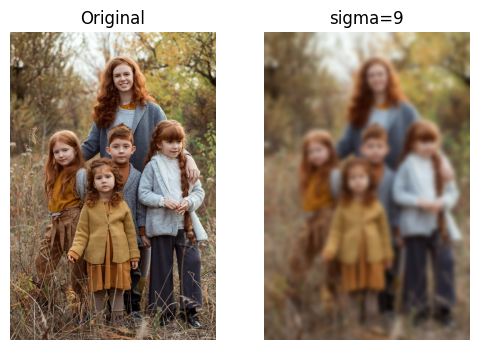

In [32]:
import cv2

from lib.utils.path import images_path

image_path = images_path() / 'family.jpg'

image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

sigma = 9  # 3, 5, 7, 9
image_blur = cv2.GaussianBlur(image, (0, 0), sigma)

fig, ax = plt.subplots(1, 2, figsize=(6, 4))
ax[0].imshow(image)
ax[0].set_title('Original')
ax[0].axis('off')
ax[1].imshow(image_blur)
ax[1].set_title(f'sigma={sigma}')
ax[1].axis('off')
plt.show()

## 3) 밝기/대비 조절

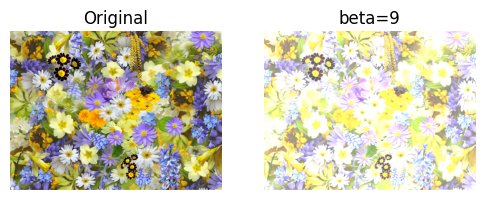

In [33]:
# 밝기 조절
import cv2

from lib.utils.path import images_path

image_path = images_path() / 'flowers.jpg'

image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

beta = 100
image_bright = cv2.convertScaleAbs(image, alpha=1, beta=beta)

fig, ax = plt.subplots(1, 2, figsize=(6, 4))
ax[0].imshow(image)
ax[0].set_title('Original')
ax[0].axis('off')
ax[1].imshow(image_bright)
ax[1].set_title(f'beta={sigma}')
ax[1].axis('off')
plt.show()

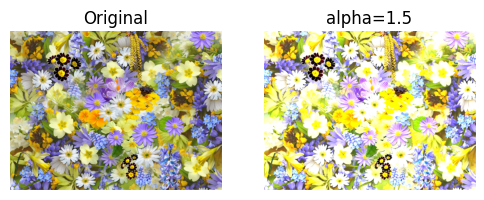

In [ ]:
# 대비 조절: 밝은 색과 어두운 색의 차이를 크게 하는 것
import cv2

from lib.utils.path import images_path

image_path = images_path() / 'flowers.jpg'

image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

alpha = 1.5
image_bright = cv2.convertScaleAbs(image, alpha=alpha, beta=1)

fig, ax = plt.subplots(1, 2, figsize=(6, 4))
ax[0].imshow(image)
ax[0].set_title('Original')
ax[0].axis('off')
ax[1].imshow(image_bright)
ax[1].set_title(f'alpha={alpha}')
ax[1].axis('off')
plt.show()